# Make a Graph

Make a Fed Challenge graph from **FRED**, an **Excel** file, or a **CSV**, and save it as a PNG.

**How to use**
1. Pick the `.venv` kernel (top right of the notebook) the first time.
2. Run **Setup** once.
3. Fill in **Settings**, then run **Settings → Load data → Make graph**.
4. To make another graph, change the settings and re-run those three cells.

The PNG is saved to `figures/png/`. Examples for every chart type are at the bottom. Paste one at the bottom of the Settings cell to start from it.

## Setup (run once)

In [1]:
import re, sys
from pathlib import Path
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd() / "code"))  # the graph tool lives in code/graph_tool
from graph_tool import load_data, preview, make_chart, save_png

## Settings
Anything set to `None` uses the default. Options for other chart types or data sources are ignored.

In [ ]:
# ---------------- 1. DATA ----------------
# FRED: series IDs separated by commas, e.g. "CPIAUCSL, CPILFESL"
#       or {"Label to show": "SERIES_ID", ...} to name the lines yourself
# File: a file name in DATA2026, e.g. "gdp_contrib.csv" or "hlb_2.xlsx"
DATA = [{"Economic Policy Uncertainty Index for United States":"USEPUINDXD"}]
START = "2022-01-01"          # "YYYY-MM-DD", or None for all data
END = None
COLUMNS = None               # which series to keep, e.g. ["Housing", "Core Goods"]; None = all
                              # a dict renames too: {"ny_fed_1": "NY Fed 1-year"}

# FRED only
UNITS = "level"                 # "level", "change", "yoy_change", "mom", "yoy", "annualized", "log"
FREQUENCY = "m"             # None (as published), "m", "q", "a", "w", "d"

# Excel only
SHEET = None                  # sheet name, or None for the first sheet with data

# ---------------- 2. CHART ----------------
CHART_TYPE = "line"           # "line", "contribution", "bar", "dual_axis"

TITLE = "Economic Policy Uncertainty Index for United States"
SUBTITLE = "Index, Monthly, Not Seasonally Adjusted"
Y_TITLE = None                # y-axis title
SOURCE = "Source: Baker, Scott R.; Bloom, Nick; Davis, Steven J. via FRED"

LABELS = None                 # rename series in the legend: {"old name": "new name"}
COLORS = None                 # {"series": "orange"}; team colors: blue, orange, light_blue, rose, dark_gray
Y_SUFFIX = ""                # text after y-axis numbers: "%", " pp", "K" ...
Y_PREFIX = ""                 # text before y-axis numbers: "$"
DECIMALS = None               # decimals on y-axis/labels; None = automatic
Y_RANGE = None                # [min, max], None = automatic
X_FORMAT = None               # date labels: "%Y", "%b %Y", "Q%q %Y"; None = automatic

REF_LINES = None  # dashed line(s): 2, [0, 2], {2: "2% target"}, or None
VLINES = None               # vertical dashed line(s) at dates: "2020-03-01", ["2020-03-01", "2022-03-01"],
                              # or {"2022-03-01": "First hike"}
RECESSIONS = True             # shade U.S. recessions
END_LABELS = None             # latest value at the end of each line; None = automatic
LEGEND = None                 # "top", "bottom", "right", "none"; None = automatic

# Contribution charts
TOTAL = None                  # column to draw as a line over the bars, "sum" to add them up, or None

# Bar charts
BAR_MODE = "group"            # "group" (side by side) or "stack"

# Dual axis charts
RIGHT_AXIS = []               # series on the right axis, e.g. ["10-Year Treasury"]
Y2_TITLE = None
Y2_SUFFIX = ""

# ---------------- 3. OUTPUT ----------------
FILE_NAME = None              # PNG name; None = made from the title ("cpi_inflation.png")
SAVE_HTML = False             # also save an interactive .html to figures/


## Load data
Prints what was found. Check that the dates and series look right before making the graph.

In [59]:
df = load_data(DATA, start=START, end=END, units=UNITS, frequency=FREQUENCY,
               sheet=SHEET, columns=COLUMNS)
preview(df)
df.tail()

Source 1: {'Economic Policy Uncertainty Index for United States': 'USEPUINDXD'}
57 rows, 2022-01-01 to 2026-09-01 (monthly)
1 series:
  - 'Economic Policy Uncertainty Index for United States': latest 294.51 on 2026-09-01


,Economic Policy Uncertainty Index for United States
Date,
2026-05-01,372.15
2026-06-01,354.84
2026-07-01,287.15
2026-08-01,234.22
2026-09-01,294.51


## Make graph

Saved /Users/zacgottschalk/Documents/Fed Graphs/NEUFed2026/figures/png/economic_policy_uncertainty_index_for_united_states.png


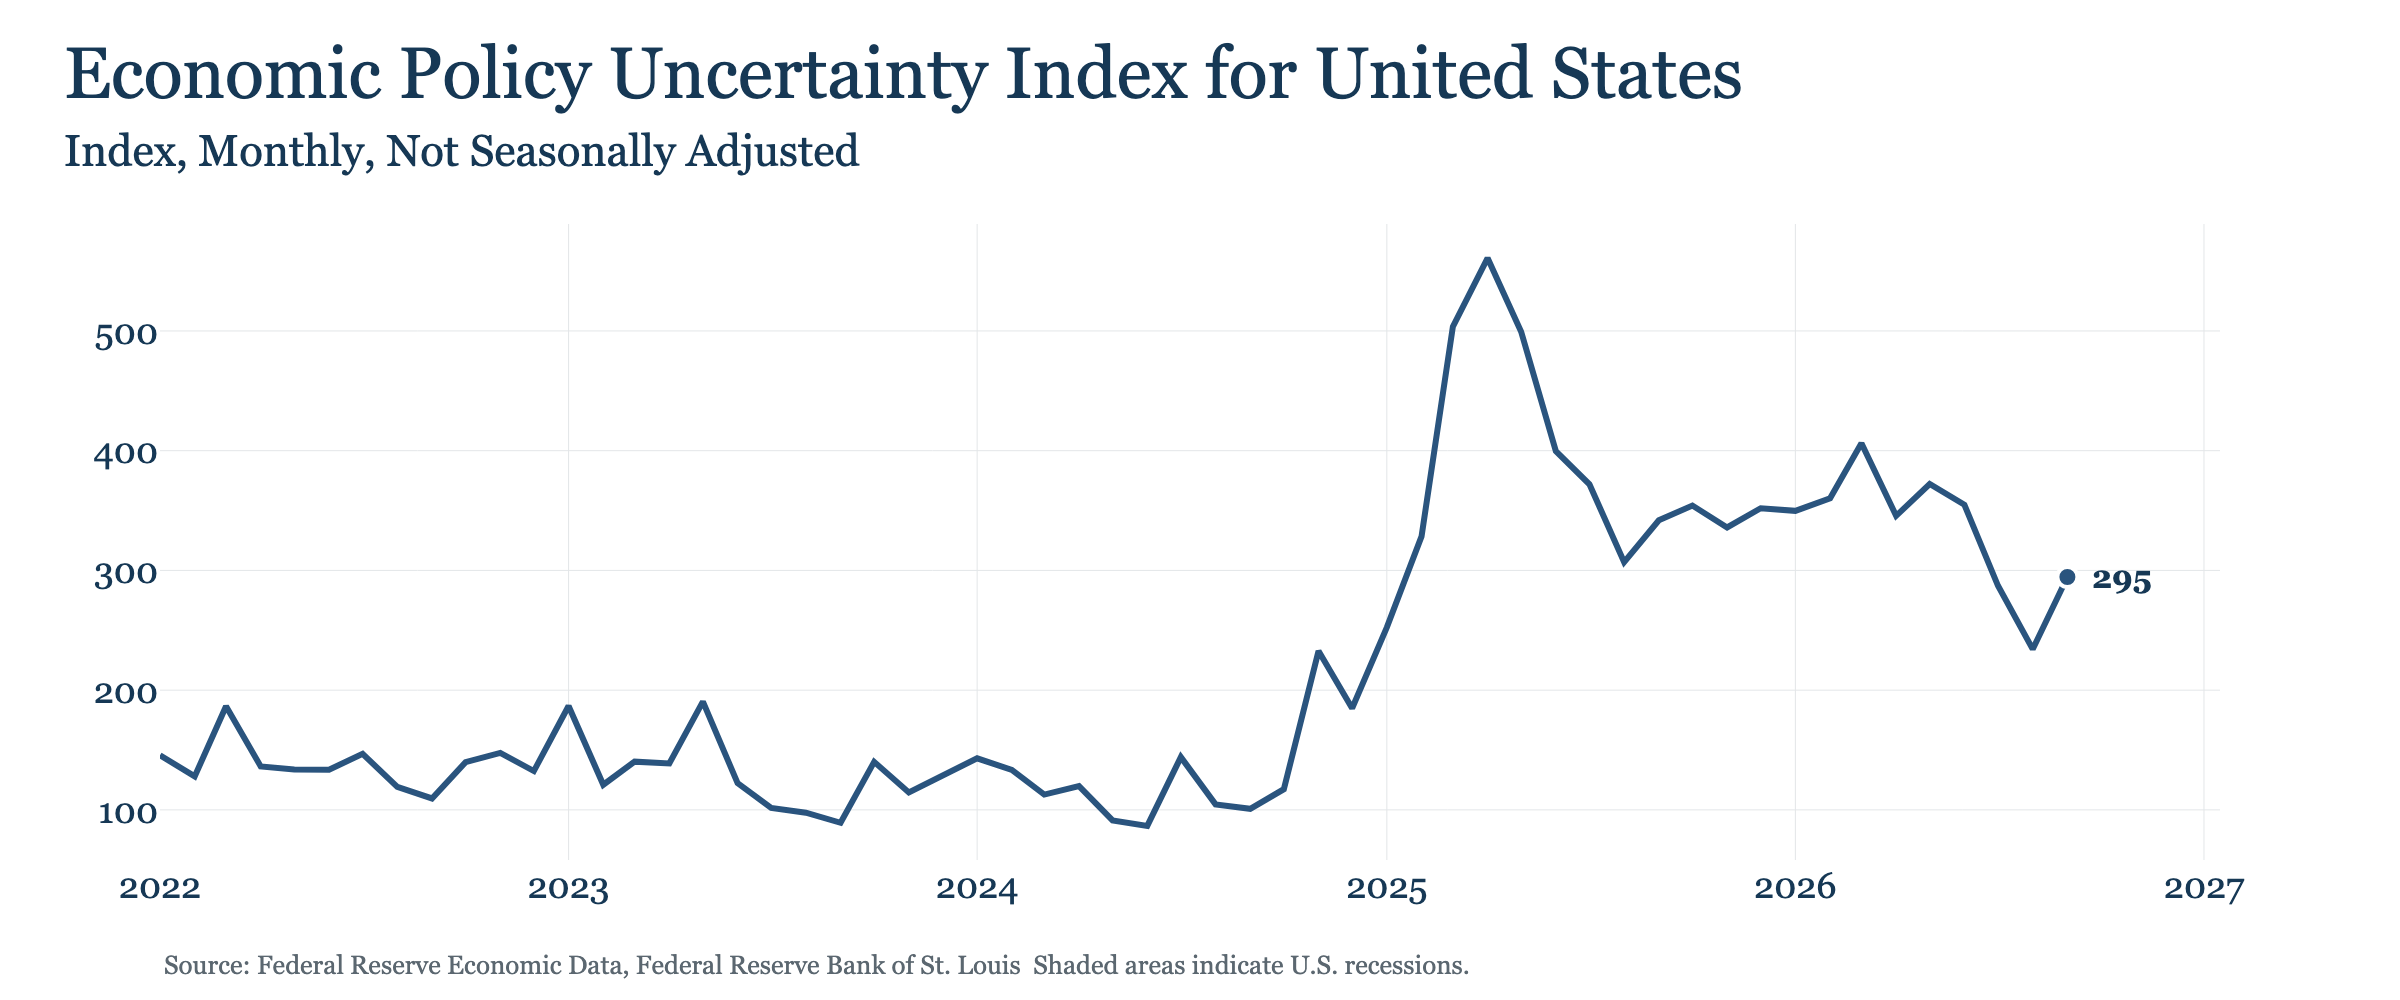

In [60]:
type_options = {
    "line": {},
    "contribution": {"total": TOTAL},
    "bar": {"mode": BAR_MODE},
    "dual_axis": {"right": RIGHT_AXIS, "y2_title": Y2_TITLE, "y2_suffix": Y2_SUFFIX},
}.get(CHART_TYPE, {})  # an unknown CHART_TYPE gets a clear error from make_chart below

fig = make_chart(
    df, CHART_TYPE,
    title=TITLE, subtitle=SUBTITLE, y_title=Y_TITLE, source=SOURCE,
    labels=LABELS, colors=COLORS,
    y_suffix=Y_SUFFIX, y_prefix=Y_PREFIX, decimals=DECIMALS, y_range=Y_RANGE, x_format=X_FORMAT,
    ref_lines=REF_LINES, vlines=VLINES,recessions=RECESSIONS, end_labels=END_LABELS, legend=LEGEND,
    **type_options,
)

name = FILE_NAME or re.sub(r"[^a-z0-9]+", "_", TITLE.lower()).strip("_") or "graph"
png_path = save_png(fig, name, html=SAVE_HTML)
print(f"Saved {png_path}")
display(Image(filename=png_path, width=900))  # exactly what the PNG looks like

---
## Examples
Paste an example at the **bottom of the Settings cell** (it overrides the lines above), then run Settings → Load data → Make graph. Settings an example doesn't mention, like `Y_TITLE` or `LEGEND`, keep their values from above.

**Line chart with FRED data, three series, a target line and recessions**
```python
DATA = {"Headline CPI": "CPIAUCSL", "Core CPI": "CPILFESL", "Core PCE": "PCEPILFE"}
UNITS = "yoy"
START = "2006-01-01"
COLUMNS = None
CHART_TYPE = "line"
TITLE = "Inflation"
SUBTITLE = "Year-over-year % change, monthly, seasonally adjusted"
Y_SUFFIX = "%"
REF_LINES = {2: "2% target"}
RECESSIONS = True
SOURCE = "Source: BLS, BEA via FRED"
```

**Unemployment rate (one series, so no legend is shown)**
```python
DATA = {"Unemployment rate": "UNRATE"}
UNITS = "level"
START = "2000-01-01"
COLUMNS = None
CHART_TYPE = "line"
TITLE = "Unemployment Rate"
SUBTITLE = "Percent, monthly, seasonally adjusted"
Y_SUFFIX = "%"
REF_LINES = None
RECESSIONS = True
SOURCE = "Source: BLS via FRED"
```

**Contribution chart from a CSV file** (pick top-level components only, not their subcategories)
```python
DATA = "gdp_contrib.csv"
START = None
COLUMNS = {"Consumption": "Consumption", "Gross private domestic investment": "Investment",
           "Net Exports": "Net Exports", "Government Spending": "Government", "Real GDP": "Real GDP"}
CHART_TYPE = "contribution"
TOTAL = "Real GDP"
TITLE = "Contributions to Real GDP Growth"
SUBTITLE = "Percentage points, quarterly, annualized"
Y_SUFFIX = " pp"
X_FORMAT = "Q%q %Y"
REF_LINES = None
RECESSIONS = False
SOURCE = "Source: BEA"
```

**Bar chart from a CSV file**
```python
DATA = "goods_services.csv"
START = "2024-01-01"
COLUMNS = None
CHART_TYPE = "bar"
BAR_MODE = "group"            # or "stack"
TITLE = "Goods vs. Services Inflation"
SUBTITLE = "Year-over-year % change, monthly"
Y_SUFFIX = "%"
X_FORMAT = "%b %Y"
REF_LINES = None
RECESSIONS = False
SOURCE = "Source: BLS"
```

**Excel file with a chosen sheet**
```python
DATA = "reserve_demand.xlsx"
START = None
SHEET = "chart data"
COLUMNS = {"Elasticity - 50th percentile (main)": "Median elasticity"}
CHART_TYPE = "line"
TITLE = "Reserve Demand Elasticity"
SUBTITLE = "Weekly"
Y_SUFFIX = ""
REF_LINES = None              # the zero line is drawn automatically
RECESSIONS = False
SOURCE = "Source: Federal Reserve Bank of New York"
```

**Dual axis chart** (two scales can suggest relationships that aren't there; use sparingly)
```python
DATA = {"S&P 500": "SP500", "10-Year Treasury": "DGS10"}
UNITS = "level"
START = "2024-01-01"
COLUMNS = None
CHART_TYPE = "dual_axis"
RIGHT_AXIS = ["10-Year Treasury"]
TITLE = "Stocks and Yields"
SUBTITLE = "Daily"
Y_TITLE = "Index"
Y2_TITLE = "Yield"
Y_SUFFIX = ""
Y2_SUFFIX = "%"
REF_LINES = None
RECESSIONS = False
SOURCE = "Source: S&P Dow Jones Indices, Federal Reserve via FRED"
```

**Troubleshooting**
- *FRED couldn't load 'XYZ'*: check the series ID. It's the code at the end of the FRED page's URL.
- *No column named ...*: the message lists the real column names and suggests close matches.
- *Strict Open XML*: open the file in Excel, File > Save As, and choose **Excel Workbook (.xlsx)**.
- *more than the 5 team colors*: use `COLUMNS` to choose 5 or fewer series.
- Wrong dates or header detected: see `load_file` in `code/graph_tool/data_sources.py` for `header_row` and `date_col`.